In [1]:
# Imports 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from numpy import ndarray
from scipy.stats import gaussian_kde
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, ConstantKernel

sns.set_theme(style="white", context="notebook")

RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)

In [ ]:
data = pd.read_csv("data/Daily_Temp_Data.csv")
data['date'] = pd.to_datetime(data['date'], dayfirst=True, errors='coerce')
data = data[(data['date'].dt.year >= 2010) & (data['date'].dt.year <= 2022)].copy()

anchor = pd.Timestamp('2010-01-01')
blocks = ((data['date'] - anchor).dt.days // 7)
data['week_start'] = anchor + blocks * pd.Timedelta(days=7)
data['temp_weekly'] = data.groupby('week_start')['temp'].transform('mean')

weekly_unique = (
    data[['week_start', 'temp_weekly']]
    .drop_duplicates(subset='week_start')
    .dropna(subset=['temp_weekly'])
    .sort_values('week_start')
)

t0 = weekly_unique['week_start'].min()
weekly_unique['t_week'] = (weekly_unique['week_start'] - t0).dt.days / 7.0

X_full = weekly_unique[['t_week']].to_numpy()
y_full = weekly_unique['temp_weekly'].to_numpy()



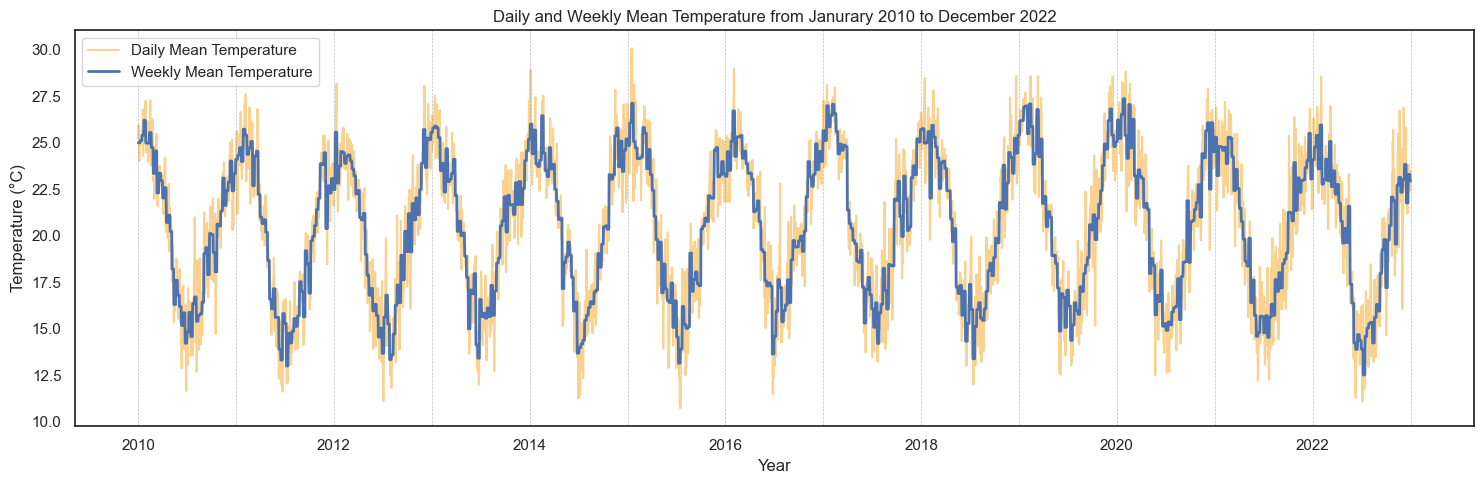

In [19]:
plt.figure(figsize=(15,5))
plt.plot(data['date'], data['temp'], label='Daily Mean Temperature', alpha=0.5, color='#F5A623')
plt.plot(data['date'], data['temp_weekly'], label='Weekly Mean Temperature', linewidth=2)

years = np.arange(2010, 2024)
for y in years:
    plt.axvline(pd.Timestamp(f'{y}-01-01'), color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.title('Daily and Weekly Mean Temperature from Janurary 2010 to December 2022')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
summary = data.describe()
print(summary)


                      date         temp                     week_start  \
count                 4748  4748.000000                           4748   
mean   2016-07-01 12:00:00    20.526029  2016-06-28 12:01:30.985678336   
min    2010-01-01 00:00:00    10.735000            2010-01-01 00:00:00   
25%    2013-04-01 18:00:00    17.263854            2013-03-29 00:00:00   
50%    2016-07-01 12:00:00    20.857142            2016-07-01 00:00:00   
75%    2019-10-01 06:00:00    23.815417            2019-09-27 00:00:00   
max    2022-12-31 00:00:00    30.074167            2022-12-30 00:00:00   
std                    NaN     3.893950                            NaN   

       temp_weekly  
count  4748.000000  
mean     20.526029  
min      12.527170  
25%      17.088062  
50%      20.879583  
75%      23.841103  
max      27.366424  
std       3.717223  


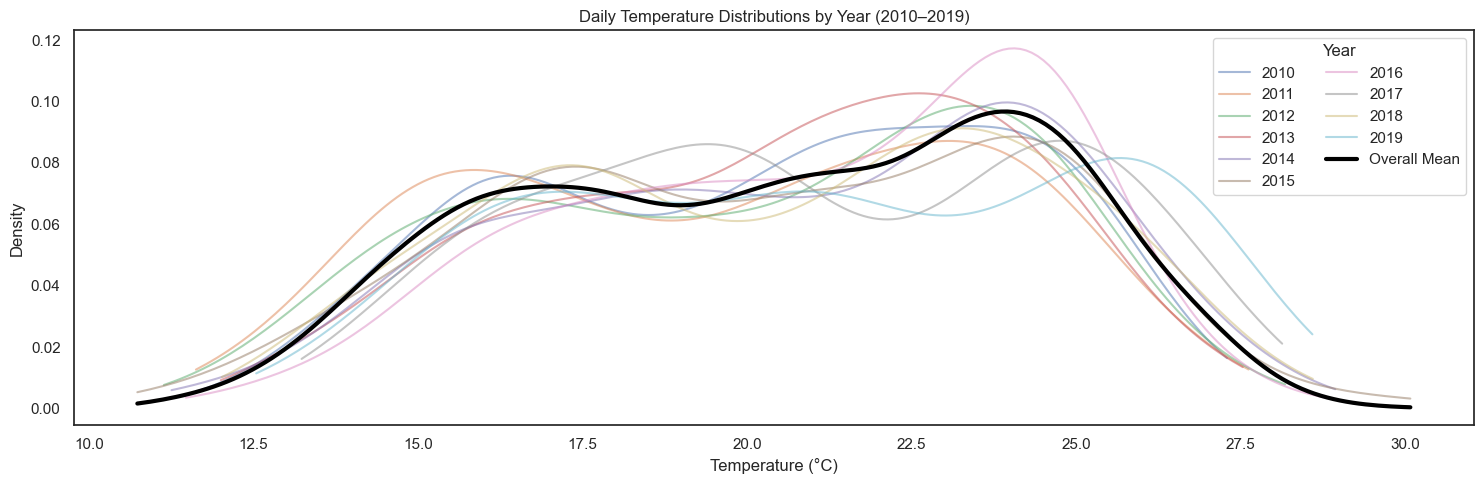

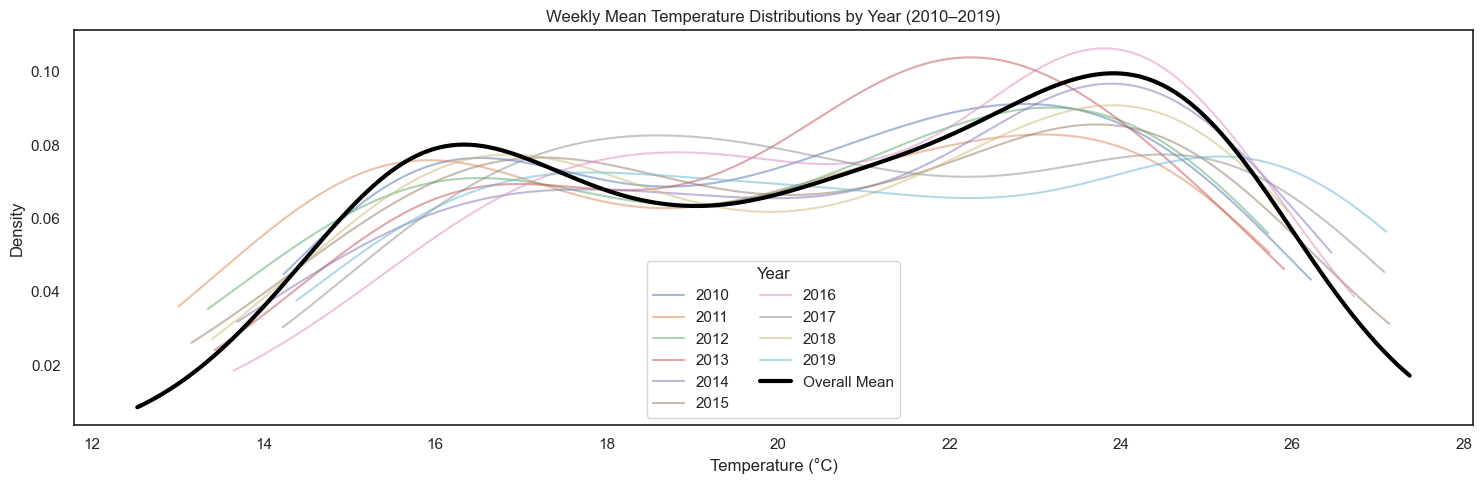

In [21]:
data['year'] = pd.to_datetime(data['week_start']).dt.year

years = range(2010, 2020)

plt.figure(figsize=(15,5))
for y in years:
    vals = data.loc[data['year'] == y, 'temp'].dropna().values
    if len(vals) > 1:
        kde = gaussian_kde(vals)
        xs = np.linspace(vals.min(), vals.max(), 200)
        plt.plot(xs, kde(xs), label=str(y), alpha=0.5)

all_vals = data['temp'].dropna().values
kde_all = gaussian_kde(all_vals)
xs_all = np.linspace(all_vals.min(), all_vals.max(), 200)
plt.plot(xs_all, kde_all(xs_all), color='black', linewidth=3, label='Overall Mean')

plt.title('Daily Temperature Distributions by Year (2010–2019)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.legend(title='Year', ncol=2)
plt.tight_layout()
plt.show()

weekly_unique = (
    data[['week_start', 'temp_weekly']]
    .drop_duplicates(subset='week_start')
    .copy()
)
weekly_unique['year'] = weekly_unique['week_start'].dt.year

plt.figure(figsize=(15,5))
for y in years:
    vals = weekly_unique.loc[weekly_unique['year'] == y, 'temp_weekly'].dropna().values
    if len(vals) > 1:
        kde = gaussian_kde(vals)
        xs = np.linspace(vals.min(), vals.max(), 200)
        plt.plot(xs, kde(xs), label=str(y), alpha=0.5)

all_vals_w = weekly_unique['temp_weekly'].dropna().values
kde_all_w = gaussian_kde(all_vals_w)
xs_all_w = np.linspace(all_vals_w.min(), all_vals_w.max(), 200)
plt.plot(xs_all_w, kde_all_w(xs_all_w), color='black', linewidth=3, label='Overall Mean')

plt.title('Weekly Mean Temperature Distributions by Year (2010–2019)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.legend(title='Year', ncol=2)
plt.tight_layout()
plt.show()


In [ ]:
train_mask = weekly_unique['week_start'].dt.year <= 2019
X_train = X_full[train_mask]
y_train = y_full[train_mask]

(522, 1)


In [ ]:
kernel_lin = ConstantKernel(1.0) * RBF(length_scale=52)  
kernel_per = ConstantKernel(1.0) * ExpSineSquared(
    length_scale=6,
    periodicity=52,              
    periodicity_bounds=(50, 54)
) * RBF(4)

kernel_noi = WhiteKernel(noise_level=0.5, noise_level_bounds=(1e-5, 1e2))
kernel = kernel_lin + kernel_per + kernel_noi

In [30]:
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=RANDOM_SEED
)
gp.fit(X_train, y_train)
print("Optimized kernel:", gp.kernel_)

Optimized kernel: 0.0996**2 * RBF(length_scale=44.2) + 3.02**2 * ExpSineSquared(length_scale=3.81, periodicity=52.2) * RBF(length_scale=8.28e+03) + WhiteKernel(noise_level=0.078)


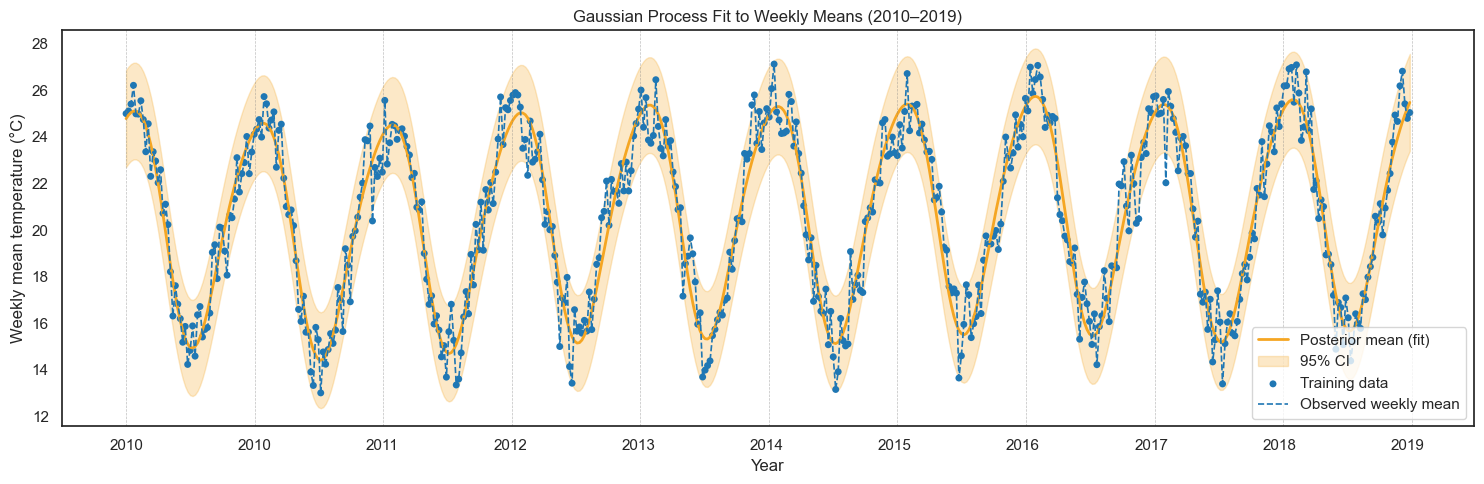

In [49]:
# GP fit on observed domain only
# Sort X_full so the line is monotone in time
order = np.argsort(X_train.ravel())
X_plot = X_train.ravel()[order].reshape(-1, 1)

y_fit, y_fit_std = gp.predict(X_plot, return_std=True)

plt.figure(figsize=(15, 5))

# GP posterior mean over observed weeks
sns.lineplot(x=X_plot.ravel(), y=y_fit, lw=2, color="#F5A623", label="Posterior mean (fit)")
plt.fill_between(
    X_plot.ravel(),
    y_fit - 1.96 * y_fit_std,
    y_fit + 1.96 * y_fit_std,
    color="#F5A623", alpha=0.25, label="95% CI"
)

# training data as dots
sns.scatterplot(x=X_train.ravel(), y=y_train, s=25, color="#1f77b4",
                edgecolor="none", label="Training data")

# optional: dashed observed weekly means (full 2010–2022)
sns.lineplot(x=X_train.ravel(), y=y_train, color="#1f77b4",
             linestyle="--", lw=1.2, label="Observed weekly mean")

# year ticks
weeks_per_year = 52
xticks = np.arange(0, X_plot.max(), weeks_per_year)
xlabels = (t0 + pd.to_timedelta(xticks * 7, unit="D")).year
plt.xticks(xticks, xlabels.astype(str))
plt.xlabel("Year")
plt.ylabel("Weekly mean temperature (°C)")
plt.title("Gaussian Process Fit to Weekly Means (2010–2019)")

# vertical year lines
for year in np.arange(2010, 2021):
    x_week = (pd.Timestamp(f"{year}-01-01") - t0).days / 7
    plt.axvline(x=x_week, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

plt.legend()
plt.tight_layout()
plt.show()


In [58]:
H = 0 * (2022 - 2010 + 1)
x_future = np.linspace(X_full.min(), X_full.max(), 1000).reshape(-1, 1)
y_pred, y_std = gp.predict(x_future, return_std=True)

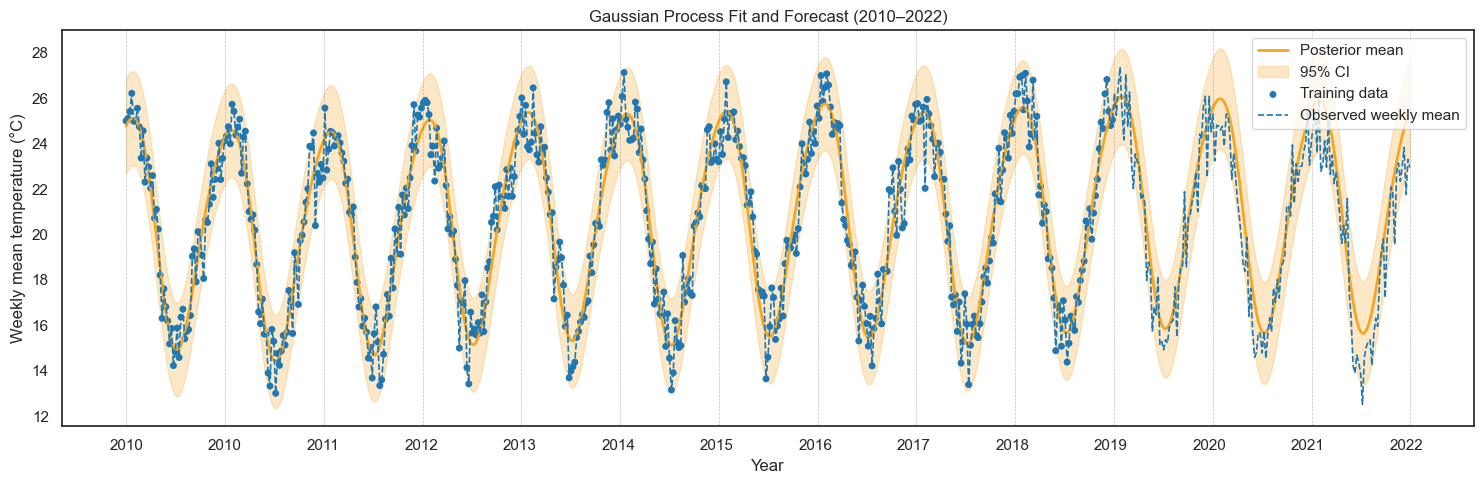

In [59]:
plt.figure(figsize=(15, 5))

sns.lineplot(x=x_future.ravel(), y=y_pred, lw=2, color="#F5A623", label="Posterior mean")
plt.fill_between(
    x_future.ravel(),
    y_pred - 1.96 * y_std,
    y_pred + 1.96 * y_std,
    color="#F5A623", alpha=0.25, label="95% CI"
)

sns.scatterplot(x=X_train.ravel(), y=y_train, s=25, color="#1f77b4", label="Training data", edgecolor="none")
sns.lineplot(x=X_full.ravel(), y=y_full, color="#1f77b4", linestyle="--", lw=1.2, label="Observed weekly mean")

weeks_per_year = 52
xticks = np.arange(0, x_future.max(), weeks_per_year)
xlabels = (t0 + pd.to_timedelta(xticks * 7, unit="D")).year
plt.xticks(xticks, xlabels.astype(str))
plt.xlabel("Year")
plt.ylabel("Weekly mean temperature (°C)")
plt.title("Gaussian Process Fit and Forecast (2010–2022)")

for year in np.arange(2010, 2024):
    x_week = (pd.Timestamp(f"{year}-01-01") - t0).days / 7
    plt.axvline(x=x_week, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

plt.legend()
plt.tight_layout()
plt.show()


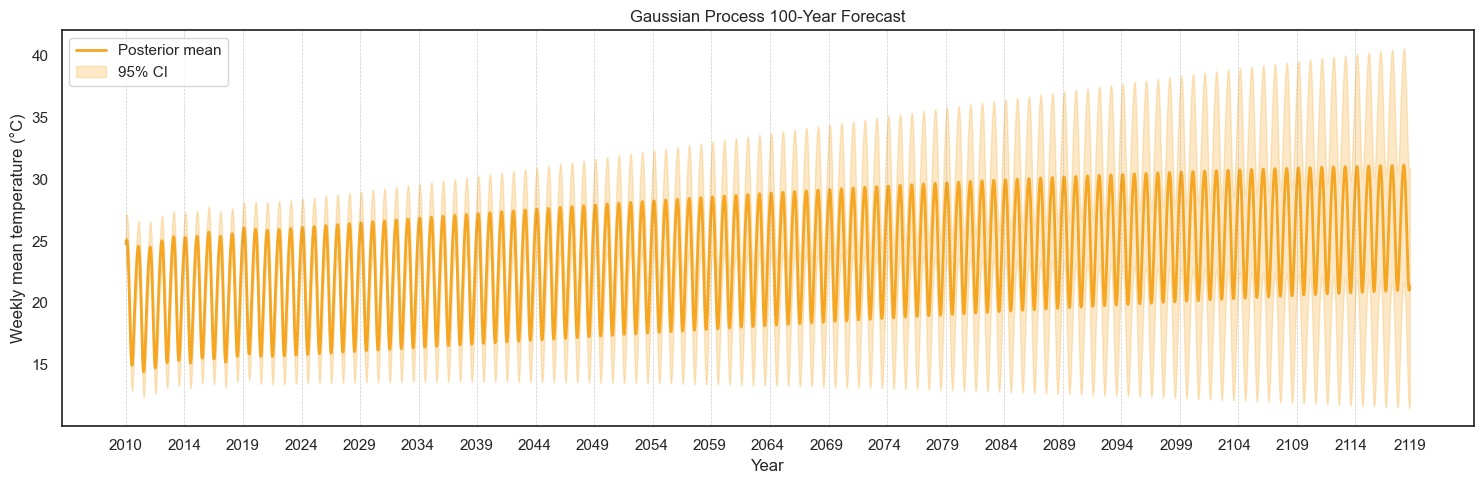

In [60]:
# 100-year forecast in weeks
years_ahead = 100
weeks_per_year = 52
x_start = float(X_train.min())
x_end   = float(X_train.max()) + years_ahead * weeks_per_year

# prediction grid and GP forecast
x_future = np.linspace(x_start, x_end, 4000).reshape(-1, 1)
y_pred, y_std = gp.predict(x_future, return_std=True)

# plot
plt.figure(figsize=(15, 5))
sns.lineplot(x=x_future.ravel(), y=y_pred, lw=2, color="#F5A623", label="Posterior mean")
plt.fill_between(
    x_future.ravel(),
    y_pred - 1.96 * y_std,
    y_pred + 1.96 * y_std,
    color="#F5A623", alpha=0.25, label="95% CI"
)

# x-axis as calendar years (tick every 5 years to avoid clutter)
step_years = 5
xticks = np.arange(0, x_end + 1, weeks_per_year * step_years)
xlabels = (t0 + pd.to_timedelta(xticks * 7, unit="D")).year
plt.xticks(xticks, xlabels.astype(str))
plt.xlabel("Year")
plt.ylabel("Weekly mean temperature (°C)")
plt.title("Gaussian Process 100-Year Forecast")

# optional vertical lines every 5 years
for y in range(int(xlabels.min()), int(xlabels.max()) + 1, step_years):
    xw = (pd.Timestamp(f"{y}-01-01") - t0).days / 7
    plt.axvline(x=xw, color="gray", linestyle="--", linewidth=0.5, alpha=0.4)

plt.legend()
plt.tight_layout()
plt.show()


# Results

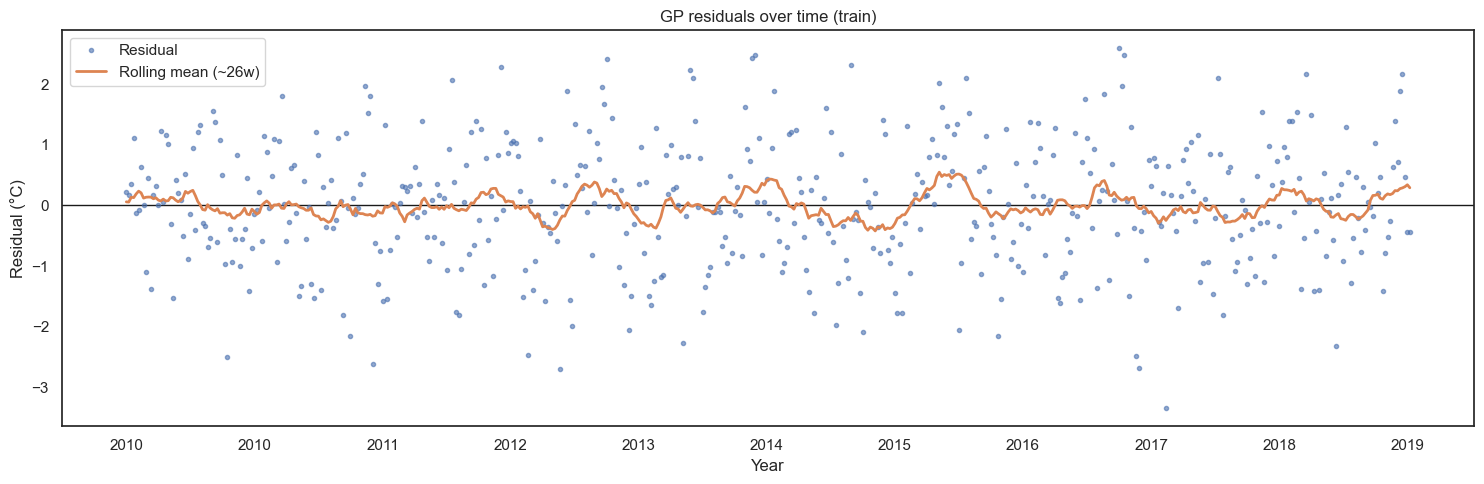

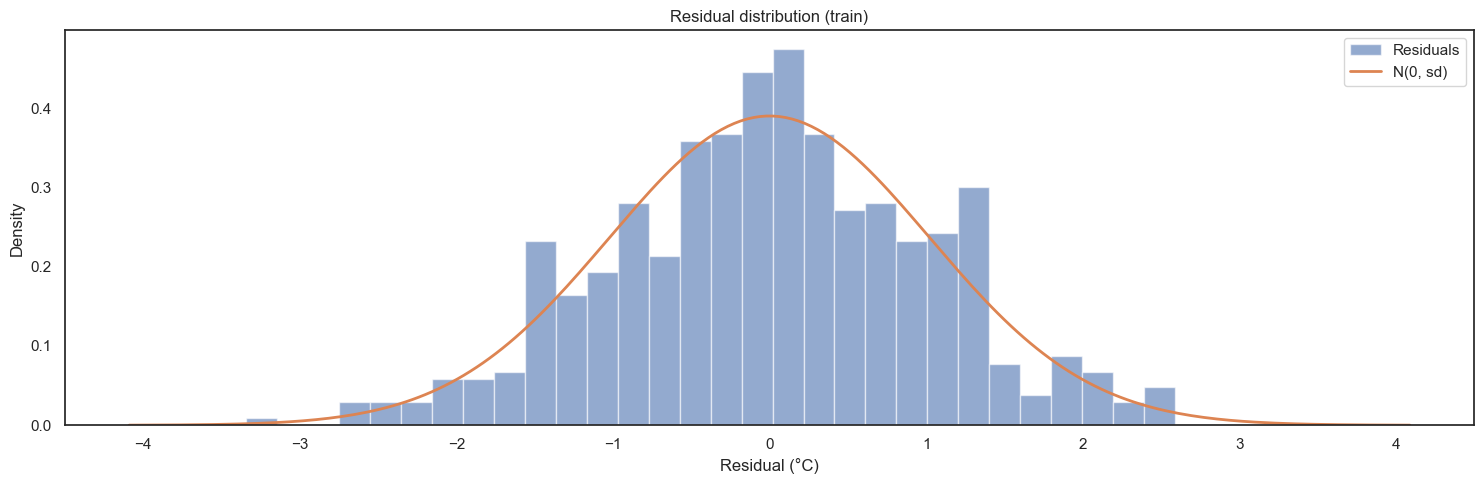

In [73]:
from scipy.stats import norm

y_tr_mean, y_tr_std = gp.predict(X_train, return_std=True)
resid = y_train - y_tr_mean

weeks_per_year = 52
xticks = np.arange(0, X_train.max()+1, weeks_per_year)
xlabels = (t0 + pd.to_timedelta(xticks * 7, unit="D")).year

plt.figure(figsize=(15,5))
plt.axhline(0, color='k', lw=1)
plt.plot(X_train.ravel(), resid, '.', alpha=0.6, label='Residual')
# Rolling mean residual (approx 26-week window)
order = np.argsort(X_train.ravel())
x_sorted = X_train.ravel()[order]
r_sorted = resid[order]
win = 26
if len(r_sorted) >= win:
    r_roll = pd.Series(r_sorted).rolling(win, center=True, min_periods=int(win/2)).mean().values
    plt.plot(x_sorted, r_roll, lw=2, label='Rolling mean (~26w)')
plt.xticks(xticks, xlabels.astype(str))
plt.xlabel("Year"); plt.ylabel("Residual (°C)")
plt.title("GP residuals over time (train)")
plt.legend(); plt.tight_layout(); plt.show()

# Residual histogram with N(0, sigmâ) overlay for quick check
plt.figure(figsize=(15,5))
plt.hist(resid, bins=30, density=True, alpha=0.6, label='Residuals')
mu, sd = np.mean(resid), np.std(resid)
xs = np.linspace(mu-4*sd, mu+4*sd, 200)
plt.plot(xs, norm.pdf(xs, loc=0, scale=sd), lw=2, label='N(0, sd)')
plt.xlabel("Residual (°C)"); plt.ylabel("Density")
plt.title("Residual distribution (train)")
plt.legend(); plt.tight_layout(); plt.show()


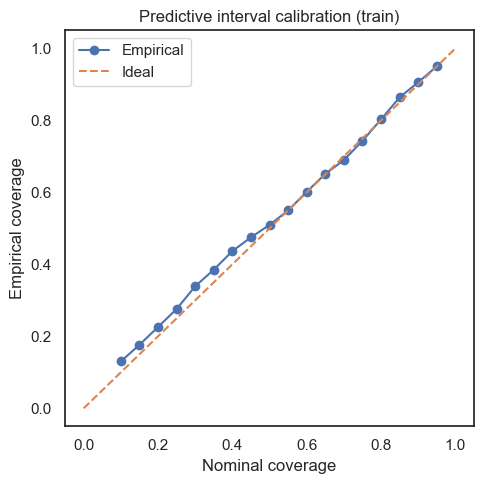

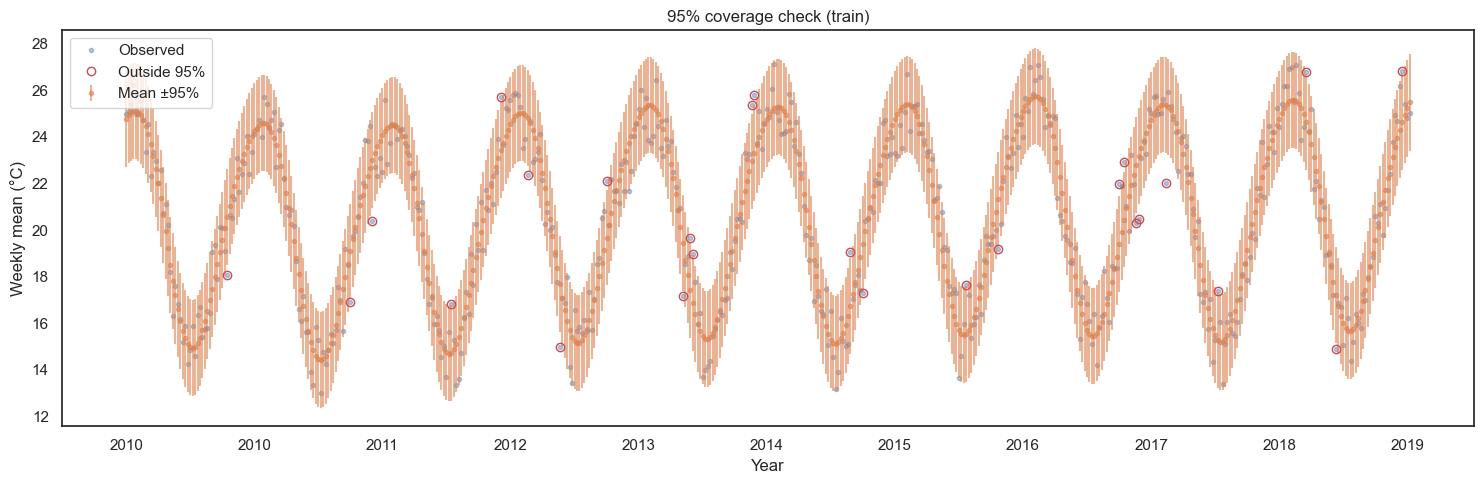

In [75]:
from scipy.stats import norm

# Empirical coverage at standard levels
levels = np.linspace(0.1, 0.95, 18)  # 0.10..0.95
emp_cov = []
yhat, ysd = y_tr_mean, y_tr_std
for p in levels:
    z = norm.ppf(0.5*(1+p))
    inside = (np.abs(y_train - yhat) <= z*ysd)
    emp_cov.append(np.mean(inside))

plt.figure(figsize=(5,5))
plt.plot(levels, emp_cov, marker='o', label='Empirical')
plt.plot([0,1],[0,1], '--', label='Ideal')
plt.xlabel("Nominal coverage"); plt.ylabel("Empirical coverage")
plt.title("Predictive interval calibration (train)")
plt.legend(); plt.tight_layout(); plt.show()

# Time series highlighting points outside 95% CI
z95 = norm.ppf(0.975)
outside = np.abs(y_train - yhat) > z95*ysd

plt.figure(figsize=(15,5))
plt.plot(X_train.ravel(), y_train, '.', alpha=0.4, label='Observed')
plt.errorbar(X_train.ravel(), yhat, yerr=z95*ysd, fmt='.', alpha=0.6, label='Mean ±95%')
plt.plot(X_train.ravel()[outside], y_train[outside], 'o', mfc='none', mec='r', ms=6, label='Outside 95%')
weeks_per_year = 52
xticks = np.arange(0, X_train.max()+1, weeks_per_year)
xlabels = (t0 + pd.to_timedelta(xticks * 7, unit="D")).year
plt.xticks(xticks, xlabels.astype(str))
plt.xlabel("Year"); plt.ylabel("Weekly mean (°C)")
plt.title("95% coverage check (train)")
plt.legend(); plt.tight_layout(); plt.show()


C:\Users\Ethan\AppData\Local\Temp\ipykernel_23360\2967311746.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nl += float(np.exp(p.theta)) if hasattr(p, 'theta') else p.noise_level


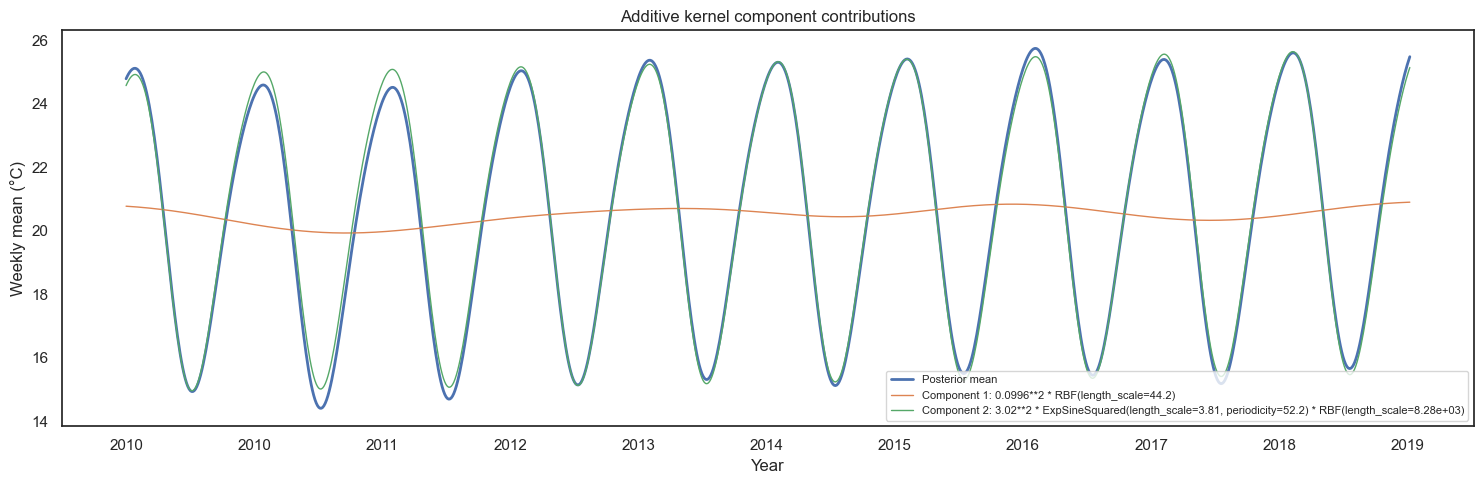

In [78]:
import numpy.linalg as npl
from sklearn.base import clone
from sklearn.gaussian_process.kernels import Kernel, WhiteKernel

# Helper: extract additive sub-kernels and noise
def split_sum_kernels(k):
    # Flattens a sum of kernels into a list; otherwise returns [k]
    from sklearn.gaussian_process.kernels import Sum
    if isinstance(k, Sum):
        return split_sum_kernels(k.k1) + split_sum_kernels(k.k2)
    else:
        return [k]

# Identify noise level from any WhiteKernel present
def get_noise_level(kern):
    parts = split_sum_kernels(kern)
    nl = 0.0
    for p in parts:
        if isinstance(p, WhiteKernel):
            nl += float(np.exp(p.theta)) if hasattr(p, 'theta') else p.noise_level
    return nl

# Build list of non-noise components
opt_kern = gp.kernel_  # optimized kernel
parts = [p for p in split_sum_kernels(opt_kern) if not isinstance(p, WhiteKernel)]
noise = get_noise_level(opt_kern)

# Training kernel matrix without noise, and alpha
Ksum = np.zeros((len(X_train), len(X_train)))
for p in parts:
    Ksum += p(X_train, X_train)
Ky = Ksum + noise*np.eye(len(X_train))

# Center y if normalize_y=True
y_center = y_train - getattr(gp, "_y_train_mean", 0.0)
alpha = npl.solve(Ky, y_center)

# Grid for plotting contributions on train domain
Xg = np.linspace(float(X_train.min()), float(X_train.max()), 1000).reshape(-1,1)

contribs = []
labels = []
for i, p in enumerate(parts, 1):
    Kig = p(Xg, X_train)
    contribs.append(Kig @ alpha)
    labels.append(f"Component {i}: {p}")

tot_mean = np.sum(contribs, axis=0)
if hasattr(gp, "_y_train_mean"):
    tot_mean = tot_mean + gp._y_train_mean  # unnormalize to original scale

# Plot total mean and components
plt.figure(figsize=(15,5))
plt.plot(Xg.ravel(), tot_mean, lw=2, label='Posterior mean')
for c, lab in zip(contribs, labels):
    plt.plot(Xg.ravel(), c + getattr(gp, "_y_train_mean", 0.0), lw=1, label=lab)
xticks = np.arange(0, Xg.max()+1, 52)
xlabels = (t0 + pd.to_timedelta(xticks * 7, unit="D")).year
plt.xticks(xticks, xlabels.astype(str))
plt.xlabel("Year"); plt.ylabel("Weekly mean (°C)")
plt.title("Additive kernel component contributions")
plt.legend(ncol=1, fontsize=8); plt.tight_layout(); plt.show()


c:\Users\Ethan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__k2__periodicity is close to the specified upper bound 54. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Ethan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Ethan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

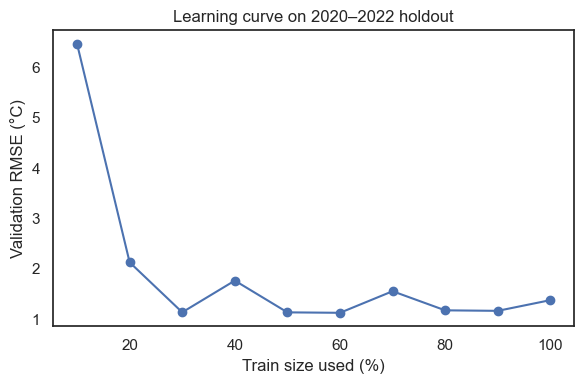

In [70]:
from sklearn.base import clone

# Fixed validation set (holdout defined above)
X_val, y_val = X_hold, y_hold

# Progressive train sizes
order_tr = np.argsort(X_train.ravel())
Xtr_sorted = X_train[order_tr]
ytr_sorted = y_train[order_tr]

sizes = np.linspace(0.1, 1.0, 10)  # 10%..100%
rmse_vals = []

for f in sizes:
    n = max(20, int(f * len(Xtr_sorted)))
    Xsub = Xtr_sorted[:n]
    ysub = ytr_sorted[:n]
    # Refit a fresh GP with the same kernel structure
    gp_sub = GaussianProcessRegressor(
        kernel=clone(gp.kernel_),
        n_restarts_optimizer=3,
        normalize_y=True,
        random_state=RANDOM_SEED
    )
    gp_sub.fit(Xsub, ysub)
    yv, sv = gp_sub.predict(X_val, return_std=True)
    rmse_vals.append(np.sqrt(np.mean((y_val - yv)**2)))

plt.figure(figsize=(6,4))
plt.plot((sizes*100).astype(int), rmse_vals, marker='o')
plt.xlabel("Train size used (%)")
plt.ylabel("Validation RMSE (°C)")
plt.title("Learning curve on 2020–2022 holdout")
plt.tight_layout(); plt.show()
